# Lab 31 — Multivariate Decomposition: PCA and ICA

In this lab you will build fMRI-like data where the ground truth is known — two "networks," each a spatial map paired with a time course, linearly mixed with noise — and then ask PCA and ICA to recover them. Because the two maps *overlap*, the true sources are **not orthogonal**, which is exactly the situation where PCA finds the right subspace but blends the sources — and where ICA's independence criterion unmixes them. Along the way you will read eigenimages and time courses off the SVD, use scree and permutation plots to choose dimensionality, and finish with a miniature group ICA plus dual regression on a simulated multi-subject dataset.

**How to run this notebook:** it runs directly in your browser (via the in-page kernel), on [Colab](https://colab.research.google.com/github/torwager/elements-of-fmri-tutorials/blob/main/part6/labs/ch31-lab-python.ipynb), or locally — it needs only numpy, scipy, matplotlib, and scikit-learn. Companion concepts are on the [chapter page](../ch31-multivariate-decomposition-pca-and-ica).

## 1. Build ground-truth sources and mix them

The decomposition model is

$$X = A\,S + E$$

where $X$ is the time $\times$ voxels data, the columns of $A$ ($T \times k$) are component **time courses**, the rows of $S$ ($k \times V$) are **spatial maps**, and $E$ is noise. We create $k = 2$ sources:

- **Spatial maps:** network 1 occupies voxels 1–150 and network 2 occupies voxels 91–255 of a 360-voxel "brain" — they share a 60-voxel overlap zone, so the maps are **not orthogonal** (like real networks that share territory). Because each map is a sparse block of on/off values, the two maps remain close to *statistically independent* — overlap costs orthogonality, not independence.
- **Time courses:** each network responds to its own train of events, convolved with a double-gamma HRF.

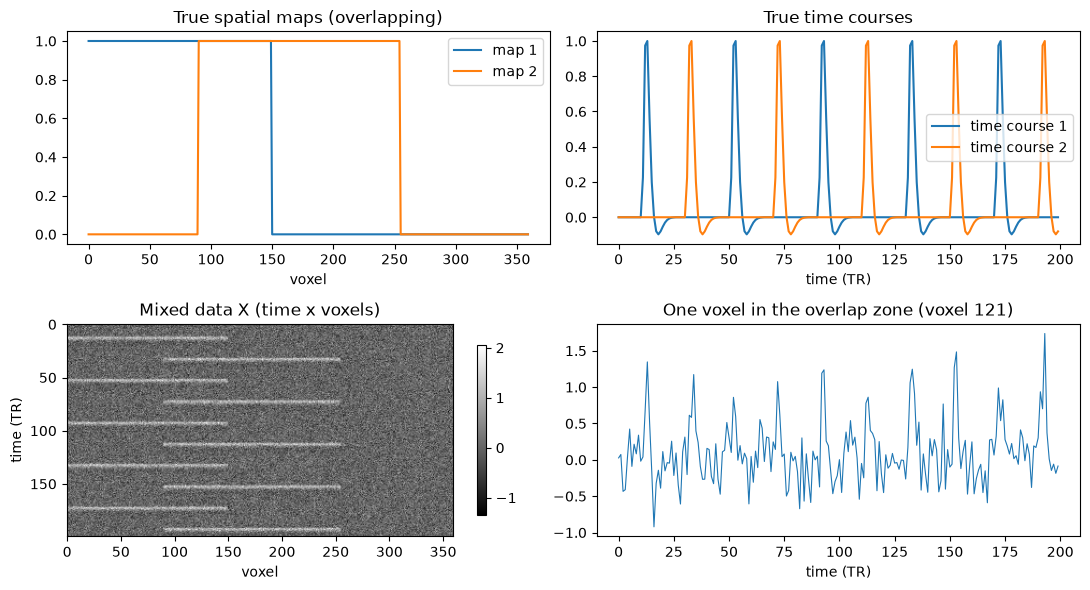

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

rng = np.random.default_rng(7)
T, V, TR = 200, 360, 2.0

# --- Spatial maps: two overlapping blocks of voxels ---
s1 = np.zeros(V); s1[0:150]  = 1.0           # network 1: voxels 1-150
s2 = np.zeros(V); s2[90:255] = 1.0           # network 2: voxels 91-255 (overlap!)
S_true = np.vstack([s1, s2])                 # k x V

# --- Time courses: event trains convolved with a double-gamma HRF ---
t_hrf = np.arange(0, 32, TR)
hrf = gamma.pdf(t_hrf, 6) - gamma.pdf(t_hrf, 16) / 6
hrf = hrf / hrf.max()

def timecourse(onsets_s):
    stick = np.zeros(T)
    stick[(np.asarray(onsets_s) / TR).astype(int)] = 1
    return np.convolve(stick, hrf)[:T]

A_true = np.column_stack([timecourse([20, 100, 180, 260, 340]),
                          timecourse([60, 140, 220, 300, 380])])  # T x k

# --- Mix and add noise ---
X = A_true @ S_true + 0.3 * rng.standard_normal((T, V))

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
axes[0, 0].plot(S_true[0], label='map 1'); axes[0, 0].plot(S_true[1], label='map 2')
axes[0, 0].set(title='True spatial maps (overlapping)', xlabel='voxel'); axes[0, 0].legend()
axes[0, 1].plot(A_true[:, 0], label='time course 1'); axes[0, 1].plot(A_true[:, 1], label='time course 2')
axes[0, 1].set(title='True time courses', xlabel='time (TR)'); axes[0, 1].legend()
im = axes[1, 0].imshow(X, aspect='auto', cmap='gray')
axes[1, 0].set(title='Mixed data X (time x voxels)', xlabel='voxel', ylabel='time (TR)')
fig.colorbar(im, ax=axes[1, 0], shrink=0.8)
axes[1, 1].plot(X[:, 120], lw=0.8)
axes[1, 1].set(title='One voxel in the overlap zone (voxel 121)', xlabel='time (TR)')
plt.tight_layout()

Voxel 121 sits in the overlap zone, so its time series is a *sum* of both networks' responses plus noise — no single-voxel analysis can tell the two sources apart there. How overlapping are the true sources? The property that matters for PCA is **orthogonality**, so we measure the cosine of the angle between the source vectors (0 = orthogonal, 1 = identical):

In [2]:
cosine = lambda a, b: a @ b / (np.linalg.norm(a) * np.linalg.norm(b))
print("Cosine similarity, spatial maps:  %.2f" % cosine(S_true[0], S_true[1]))
print("Cosine similarity, time courses:  %.2f" % cosine(A_true[:, 0], A_true[:, 1]))

Cosine similarity, spatial maps:  0.38
Cosine similarity, time courses:  0.00


The spatial maps overlap substantially (cosine $\approx 0.4$) — the sources are far from orthogonal, even though the time courses happen to be nearly orthogonal. Keep this in mind: **PCA's spatial components are forced to be mutually orthogonal**, so it *cannot* return these maps as they are.

## 2. PCA via the SVD

PCA of the mean-centered data comes from the singular value decomposition

$$X_c = U S V^T,$$

where the rows of $V^T$ are **eigenimages** (spatial modes), the columns of $U$ are their **time courses**, and the squared singular values, normalized by their sum, give the proportion of variance each component explains. To decide how many components are "real," we also build a **permutation null**: shuffle each voxel's time series independently (destroying shared structure while keeping each voxel's distribution) and recompute the spectrum.

Variance explained by PCs 1-5:  [23.4 12.2  1.   1.   0.9]


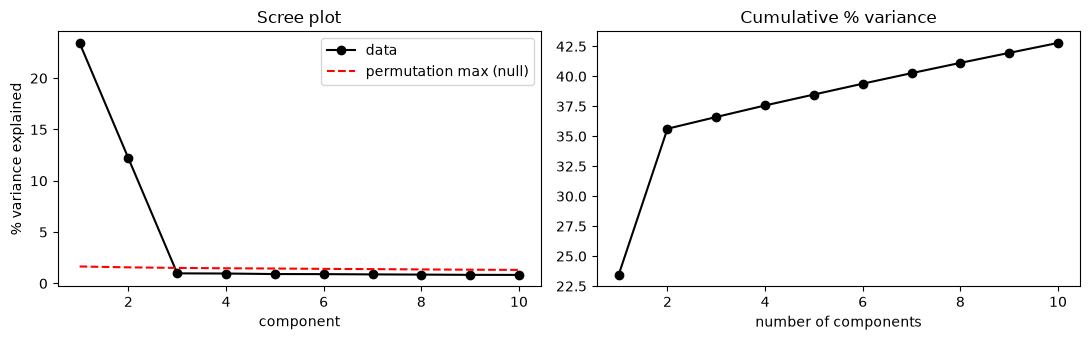

In [3]:
Xc = X - X.mean(axis=0)
U, sv, Vt = np.linalg.svd(Xc, full_matrices=False)
var_explained = 100 * sv**2 / np.sum(sv**2)

# Permutation null: shuffle each column (voxel) independently, 20 times
null_spectra = []
for _ in range(20):
    Xp = np.column_stack([rng.permutation(Xc[:, j]) for j in range(V)])
    sv_p = np.linalg.svd(Xp, compute_uv=False)
    null_spectra.append(100 * sv_p**2 / np.sum(sv_p**2))
null_spectra = np.array(null_spectra)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
k_show = 10
axes[0].plot(np.arange(1, k_show + 1), var_explained[:k_show], 'ko-', label='data')
axes[0].plot(np.arange(1, k_show + 1), null_spectra.max(axis=0)[:k_show], 'r--',
             label='permutation max (null)')
axes[0].set(title='Scree plot', xlabel='component', ylabel='% variance explained')
axes[0].legend()
axes[1].plot(np.arange(1, k_show + 1), np.cumsum(var_explained)[:k_show], 'ko-')
axes[1].set(title='Cumulative % variance', xlabel='number of components')
plt.tight_layout()

print("Variance explained by PCs 1-5: ", var_explained[:5].round(1))

The scree plot shows the classic signature: two components tower above a flat noise floor, and the curve has an **elbow** at component 3. The permutation line makes the judgment objective — only the first two components explain more variance than the maximum seen in randomized data. The standard rules (elbow, variance threshold, eigenvalue > 1, permutation) agree here: keep $k = 2$.

### Did PCA recover the sources?

The subspace, yes. The sources themselves, no. Compare the first two eigenimages with the true maps:

|correlation| between true maps (rows) and PC maps (columns):
[[0.58 0.78]
 [0.73 0.68]]


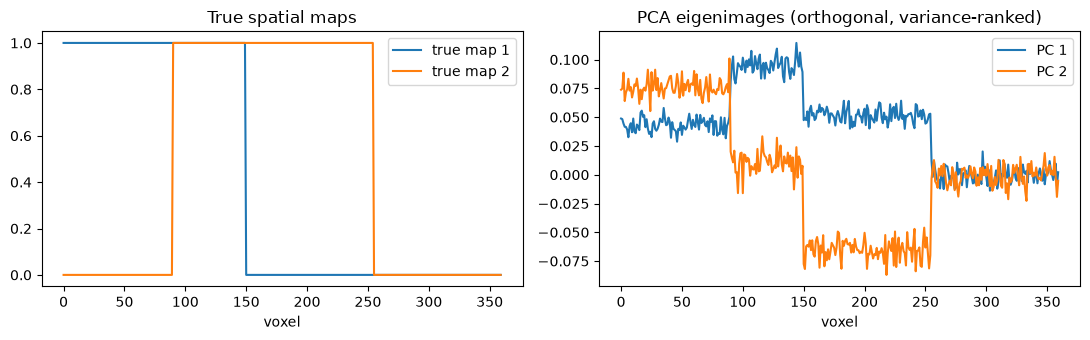

In [4]:
pc_maps = Vt[:2]                       # eigenimages, k x V
pc_time = U[:, :2] * sv[:2]            # their time courses

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(S_true[0], 'C0', label='true map 1'); axes[0].plot(S_true[1], 'C1', label='true map 2')
axes[0].set(title='True spatial maps', xlabel='voxel'); axes[0].legend()
sgn = np.sign(pc_maps.sum(axis=1, keepdims=True))   # flip for display only
axes[1].plot((sgn * pc_maps)[0], 'C0', label='PC 1'); axes[1].plot((sgn * pc_maps)[1], 'C1', label='PC 2')
axes[1].set(title='PCA eigenimages (orthogonal, variance-ranked)', xlabel='voxel'); axes[1].legend()
plt.tight_layout()

cc = np.abs(np.corrcoef(S_true, pc_maps)[:2, 2:])
print("|correlation| between true maps (rows) and PC maps (columns):")
print(cc.round(2))

Each PC correlates moderately with *both* true maps: PC 1 is a variance-weighted blend spanning both networks, and PC 2 is a *difference* component — the orthogonal remainder — with opposite signs over the two blocks. PCA has rotated the axes away from the sources to satisfy orthogonality and variance ranking. This is not a bug; it is what PCA is *for*. And the subspace it found is exactly right, as the reconstruction shows:

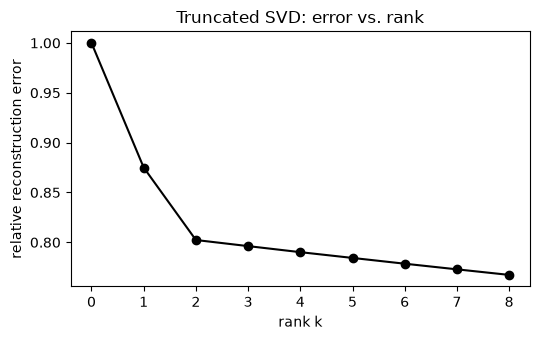

In [5]:
# Rank-k reconstruction error: ||X_c - X_k|| / ||X_c||
errs = []
for k in range(0, 9):
    Xk = (U[:, :k] * sv[:k]) @ Vt[:k]
    errs.append(np.linalg.norm(Xc - Xk) / np.linalg.norm(Xc))
plt.figure(figsize=(5.5, 3.5))
plt.plot(range(0, 9), errs, 'ko-')
plt.xlabel('rank k'); plt.ylabel('relative reconstruction error')
plt.title('Truncated SVD: error vs. rank')
plt.tight_layout()

The error plummets through $k = 2$ and then flattens — beyond rank 2, additional components only reproduce noise. This is why PCA is the standard *pre-reduction* step before ICA: it hands ICA a compact, nearly noise-free subspace to search within.

## 3. Spatial ICA unmixes the sources

ICA models $X = AS$ with the rows of $S$ **statistically independent** — a stronger requirement than uncorrelated, involving the full distributions rather than just second moments, but one that (unlike orthogonality) our overlapping sparse maps nearly satisfy. The maps are strongly non-Gaussian (each voxel's weight is either 0 or 1), and mixtures of non-Gaussian sources are more Gaussian than the sources themselves — so maximizing the non-Gaussianity of the recovered maps should point the axes back at the true sources.

We use **FastICA** in the *spatial ICA* orientation standard for fMRI: the voxels are the samples over which independence is assessed, so we hand the algorithm $X_c^T$ (voxels in rows). scikit-learn then returns the independent spatial maps as sources and the time courses as the mixing matrix — internally it first whitens and PCA-reduces the data to `n_components` dimensions, just as fMRI ICA pipelines do.

|correlation| between true maps (rows) and ICA maps (columns):
[[0.98 0.05]
 [0.05 0.98]]
|correlation| between true and ICA time courses:
[[0.99 0.11]
 [0.12 0.99]]


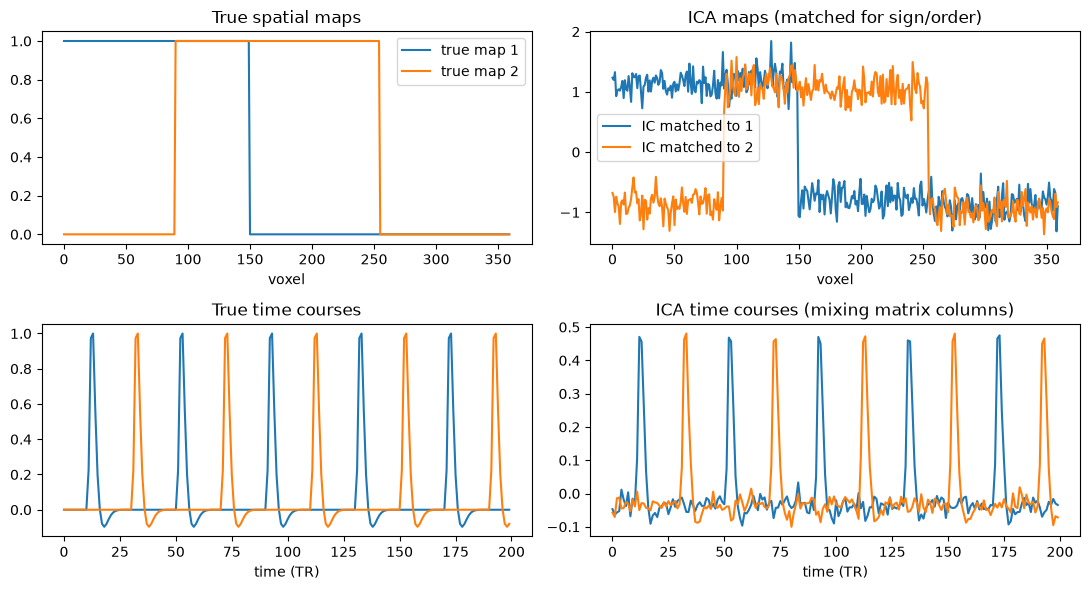

In [6]:
from sklearn.decomposition import FastICA

ica = FastICA(n_components=2, random_state=0, whiten='unit-variance')
ic_maps = ica.fit_transform(Xc.T).T              # k x V independent spatial maps
ic_time = ica.mixing_                            # T x k component time courses

# Match ICA components to true sources (order and sign are arbitrary in ICA)
cc_signed = np.corrcoef(S_true, ic_maps)[:2, 2:]           # true x IC
order = np.argmax(np.abs(cc_signed), axis=1)               # best IC per source
signs = np.sign(cc_signed[[0, 1], order])
ic_maps_m = ic_maps[order] * signs[:, None]
ic_time_m = ic_time[:, order] * signs[None, :]

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
axes[0, 0].plot(S_true[0], 'C0', label='true map 1'); axes[0, 0].plot(S_true[1], 'C1', label='true map 2')
axes[0, 0].set(title='True spatial maps', xlabel='voxel'); axes[0, 0].legend()
axes[0, 1].plot(ic_maps_m[0], 'C0', label='IC matched to 1'); axes[0, 1].plot(ic_maps_m[1], 'C1', label='IC matched to 2')
axes[0, 1].set(title='ICA maps (matched for sign/order)', xlabel='voxel'); axes[0, 1].legend()
axes[1, 0].plot(A_true[:, 0], 'C0'); axes[1, 0].plot(A_true[:, 1], 'C1')
axes[1, 0].set(title='True time courses', xlabel='time (TR)')
axes[1, 1].plot(ic_time_m[:, 0], 'C0'); axes[1, 1].plot(ic_time_m[:, 1], 'C1')
axes[1, 1].set(title='ICA time courses (mixing matrix columns)', xlabel='time (TR)')
plt.tight_layout()

print("|correlation| between true maps (rows) and ICA maps (columns):")
print(np.abs(np.corrcoef(S_true, ic_maps_m)[:2, 2:]).round(2))
print("|correlation| between true and ICA time courses:")
print(np.abs(np.corrcoef(A_true.T, ic_time_m.T)[:2, 2:]).round(2))

Each ICA component correlates near 1.0 with exactly one true source — the overlapping, non-orthogonal maps are recovered essentially intact, along with their time courses. PCA and ICA searched the *same* two-dimensional subspace; the independence criterion is what rotated the axes onto the sources.

Notice what we had to do to display the result: **match order and flip signs by hand**. ICA components come with arbitrary sign, scale, and order, and are not ranked by variance — in real data you must inspect and label them (and this ambiguity is one motivation for template-based approaches like dual regression against fixed network maps).

## 4. A miniature group analysis: temporal concatenation + dual regression

Real studies run ICA on a *group*. The standard recipe: **temporally concatenate** all subjects' data into one tall $(NT) \times V$ matrix, run one spatial ICA to get group maps, then use **dual regression** to recover subject-specific time courses and maps:

1. **Spatial regression** — regress each subject's data onto the group maps → a time course per component, per subject.
2. **Temporal regression** — regress the same subject's data onto those time courses → subject-specific spatial maps.

We simulate 6 subjects who share the two networks but differ in ways dual regression should detect: each subject **expresses network 2 with a different amplitude**, and network 2's spatial position **shifts slightly** from subject to subject.

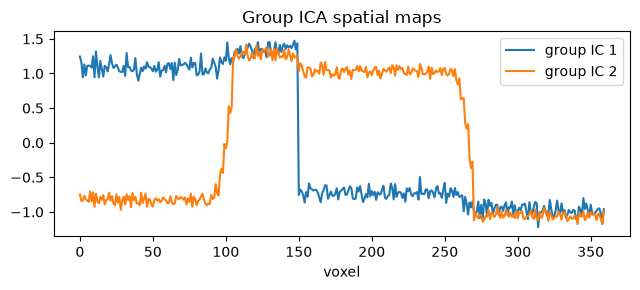

In [7]:
rng = np.random.default_rng(11)                # fresh seed for the group study
n_subj = 6
amp2_true = np.linspace(0.5, 2.0, n_subj)      # network-2 amplitude per subject

subj_data, subj_maps_true = [], []
for i in range(n_subj):
    s2_i = np.zeros(V); s2_i[90 + 3 * i : 255 + 3 * i] = 1.0   # shifted network 2
    S_i = np.vstack([s1, s2_i])
    ons1 = 20 + 80 * np.arange(5) + rng.integers(-2, 3, 5) * TR
    ons2 = 60 + 80 * np.arange(5) + rng.integers(-2, 3, 5) * TR
    A_i = np.column_stack([timecourse(ons1), amp2_true[i] * timecourse(ons2)])
    Y_i = A_i @ S_i + 0.3 * rng.standard_normal((T, V))
    subj_data.append(Y_i); subj_maps_true.append(S_i)

# --- Group spatial ICA on the temporally concatenated data ---
Y_group = np.vstack(subj_data)                      # (N*T) x V
Y_group = Y_group - Y_group.mean(axis=0)
gica = FastICA(n_components=2, random_state=0, whiten='unit-variance')
G = gica.fit_transform(Y_group.T).T                 # group maps, k x V

# Match group ICs to the canonical sources for readable output
cc = np.corrcoef(S_true, G)[:2, 2:]
order = np.argmax(np.abs(cc), axis=1); signs = np.sign(cc[[0, 1], order])
G = G[order] * signs[:, None]

plt.figure(figsize=(6.5, 3))
plt.plot(G[0], 'C0', label='group IC 1'); plt.plot(G[1], 'C1', label='group IC 2')
plt.title('Group ICA spatial maps'); plt.xlabel('voxel'); plt.legend(); plt.tight_layout()

The group maps look like consensus versions of the two networks (network 2's edges are smoothed across subjects' shifted borders). Now run dual regression for each subject. With $G$ as the group maps ($k \times V$), the two stages are just two least-squares fits:

$$\hat{A}_i = Y_i\, G^{+} \qquad \text{(stage 1: time courses)}, \qquad
\hat{S}_i = \hat{A}_i^{+}\, Y_i \qquad \text{(stage 2: maps)}$$

Correlation(true amplitude, recovered amplitude): 1.00
Mean map correlation with OWN true map:      0.98
Mean map correlation with OTHERS' true maps: 0.91


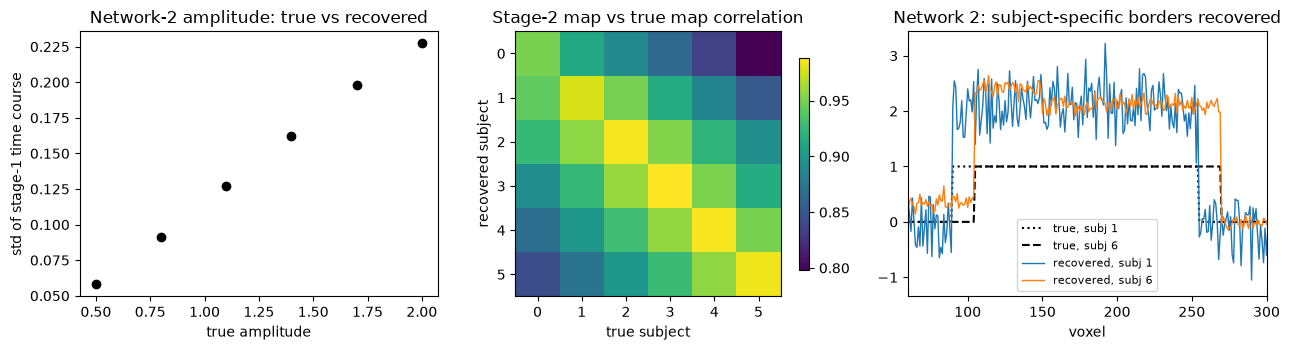

In [8]:
A_hat, S_hat = [], []
for Y_i in subj_data:
    Yc = Y_i - Y_i.mean(axis=0)
    A_i = Yc @ np.linalg.pinv(G)              # stage 1: spatial regression -> T x k
    S_i = np.linalg.pinv(A_i) @ Yc            # stage 2: temporal regression -> k x V
    A_hat.append(A_i); S_hat.append(S_i)

# (a) Subject-specific amplitude of network 2, from the stage-1 time courses
amp2_hat = np.array([A_i[:, 1].std() for A_i in A_hat])

# (b) Subject-specific maps: does each subject's stage-2 map match their OWN truth?
map_corr = np.array([[np.corrcoef(S_hat[i][1], subj_maps_true[j][1])[0, 1]
                      for j in range(n_subj)] for i in range(n_subj)])

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].plot(amp2_true, amp2_hat, 'ko')
axes[0].set(title='Network-2 amplitude: true vs recovered',
            xlabel='true amplitude', ylabel='std of stage-1 time course')
im = axes[1].imshow(map_corr, cmap='viridis')
axes[1].set(title='Stage-2 map vs true map correlation',
            xlabel='true subject', ylabel='recovered subject')
fig.colorbar(im, ax=axes[1], shrink=0.8)
axes[2].plot(subj_maps_true[0][1], 'k:', label='true, subj 1')
axes[2].plot(subj_maps_true[5][1], 'k--', label='true, subj 6')
axes[2].plot(S_hat[0][1], 'C0', lw=1, label='recovered, subj 1')
axes[2].plot(S_hat[5][1], 'C1', lw=1, label='recovered, subj 6')
axes[2].set(title='Network 2: subject-specific borders recovered', xlabel='voxel',
            xlim=(60, 300))
axes[2].legend(fontsize=8)
plt.tight_layout()

print("Correlation(true amplitude, recovered amplitude): %.2f"
      % np.corrcoef(amp2_true, amp2_hat)[0, 1])
print("Mean map correlation with OWN true map:      %.2f" % map_corr.diagonal().mean())
print("Mean map correlation with OTHERS' true maps: %.2f"
      % map_corr[~np.eye(n_subj, dtype=bool)].mean())

Dual regression recovers both kinds of individual differences from a *single group decomposition*: the stage-1 time courses track each subject's expression amplitude almost perfectly, and the stage-2 maps follow each subject's own (shifted) network borders — the correlation matrix is diagonally dominant, meaning each recovered map matches its own subject's truth better than the other subjects' truths. In a real study, these subject-level outputs feed group inference: voxel-wise t-tests on the stage-2 maps, and GLMs relating stage-1 time courses to tasks, behavior, or clinical status.

## Summary

- Decomposition factors time $\times$ voxels data into paired spatial maps and time courses; the components are latent variables.
- PCA/SVD finds orthogonal, variance-ranked components: ideal for compression, denoising, dimensionality assessment (scree + permutation), and pre-reduction — but its axes cannot coincide with overlapping (non-orthogonal) sources.
- Spatial ICA replaces orthogonality with statistical independence, exploiting non-Gaussianity to unmix overlapping sources — at the cost of arbitrary sign, scale, and order.
- Group ICA (temporal concatenation) plus dual regression yields subject-specific time courses and maps, enabling group-level inference on network expression.

**Explore further:** shrink the overlap to zero *and* give the two networks different amplitudes — with orthogonal maps and unequal variances, PCA's axes snap onto the true sources. Or increase the noise and the subject-to-subject map shifts in Section 4 and watch group ICA and dual regression degrade gracefully. Then return to the [chapter page](../ch31-multivariate-decomposition-pca-and-ica) or continue to network analysis in Chapter 32.